In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.mmlib.analyse_data import get_sim_data
from specula.mmlib.utils import show_psf, get_reference_psf, get_pupil_mask
from specula.lib.radial_profile import compute_radial_profile

from specula.lib.calc_psf import calc_psf

2026-06-01 17:27:24,816 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-01 17:27:24,924 [INFO]: [specula]: Default device is GPU number 0
2026-06-01 17:27:25,787 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-01 17:27:25,787 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-01 17:27:25,788 [INFO]: [specula]: Default device is GPU number 0
2026-06-01 17:27:25,788 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import pandas as pd
df = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_CAO.csv')
df_cut = df[df['sr']>0.63]
# df_cut

df_f1 = df[df['freq']==1000]
df_f2 = df[df['freq']==2000]
df_f4 = df[df['freq']==4000]

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'SR matrix over gain1 / gain2'}, xlabel='gain2', ylabel='gain1'>)

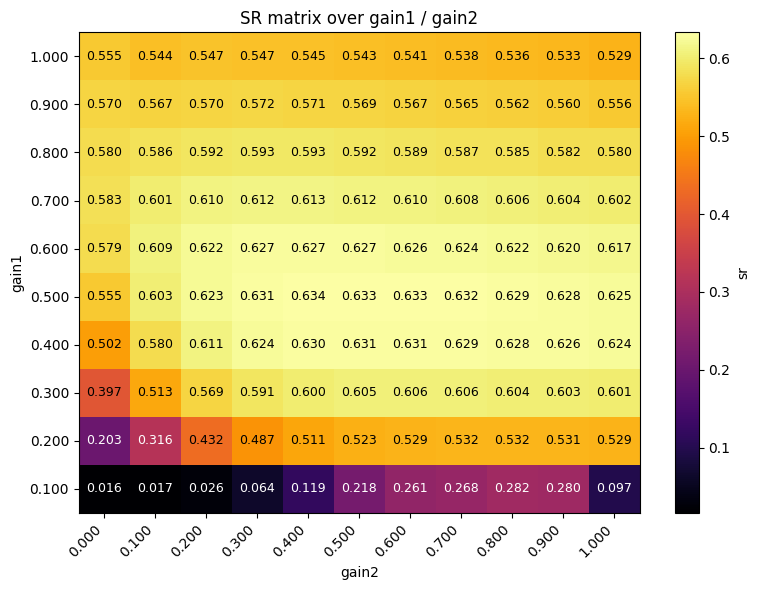

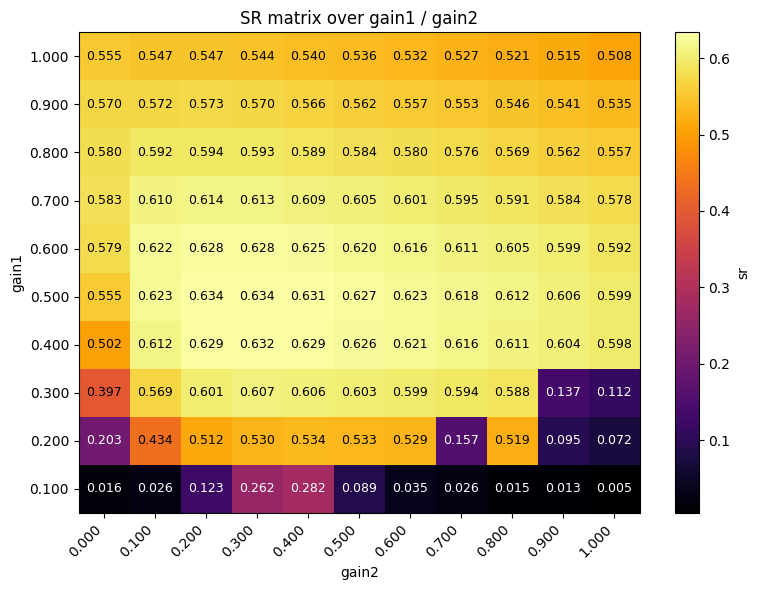

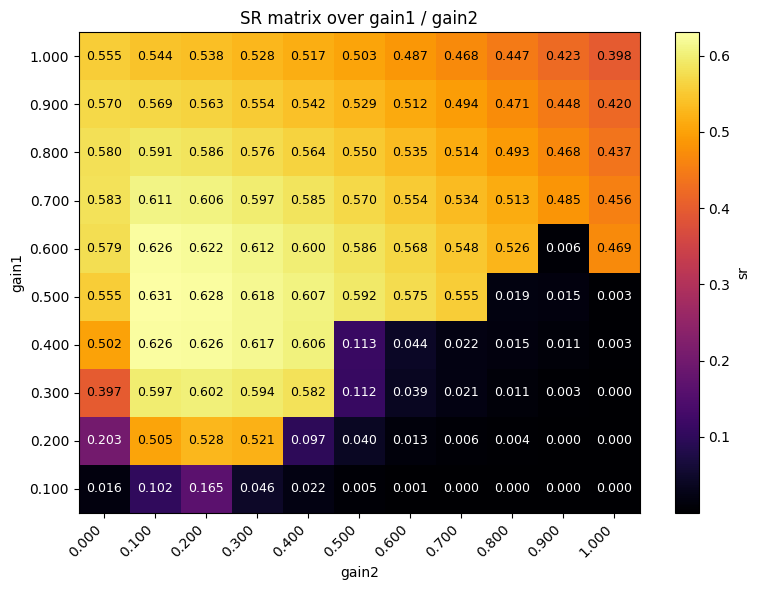

In [3]:
def show_gain_matrix(df, cmap='inferno', figsize=(8, 6), vmin=None, vmax=None):

    # Use only gain1, gain2 and sr values; ignore freq
    gain1_values = np.unique(df['gain1'])
    gain2_values = np.unique(df['gain2'])

    gain1_index = {g: i for i, g in enumerate(gain1_values)}
    gain2_index = {g: i for i, g in enumerate(gain2_values)}

    sr_matrix = np.full((gain1_values.size, gain2_values.size), np.nan, dtype=float)
    for _, row in df.iterrows():
        sr_matrix[gain1_index[row['gain1']], gain2_index[row['gain2']]] = row['sr']

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(sr_matrix, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('sr')

    ax.set_xticks(np.arange(gain2_values.size))
    ax.set_xticklabels([f'{g:1.3f}' for g in gain2_values], rotation=45, ha='right')
    ax.set_yticks(np.arange(gain1_values.size))
    ax.set_yticklabels([f'{g:1.3f}' for g in gain1_values])

    ax.set_xlabel('gain2')
    ax.set_ylabel('gain1')
    ax.set_title('SR matrix over gain1 / gain2')

    threshold = (np.nanmin(sr_matrix) + np.nanmax(sr_matrix)) / 2.0
    for i in range(gain1_values.size):
        for j in range(gain2_values.size):
            value = sr_matrix[i, j]
            if np.isfinite(value):
                text_color = 'white' if value < threshold else 'black'
                ax.text(j, i, f'{value:1.3f}', ha='center', va='center', color=text_color, fontsize=9)

    plt.tight_layout()
    return fig, ax

# Example usage
show_gain_matrix(df_f1)
show_gain_matrix(df_f2)
show_gain_matrix(df_f4)


In [4]:

dfd = pd.read_csv('/raid1/mmenessini/results/Cascading/e2e_csv/ristretto_faint_dCAO.csv')
dfd

,freq,sr,gain1,gain2,IIR1,IIR2
0,NaN,0.651191,0.1,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
1,NaN,0.608793,0.2,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
2,NaN,0.509894,0.3,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
3,NaN,0.393995,0.4,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
4,NaN,0.271951,0.5,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
5,NaN,0.167142,0.6,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
6,NaN,0.079547,0.7,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
7,NaN,0.023274,0.8,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
8,NaN,0.001932,0.9,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0
9,NaN,0.000053,1.0,0.0,iirfilter_1300modes_exc1_pow1.5,iirfilter_150modes_exc2_pow1.0


In [5]:
def calc_coro_psf(phase,amp,use_average_field:bool=True,norm=None,oversampling:int=4):    
    # L = np.max(phase.shape)
    # phase -= np.mean(phase)
    # pad_amp = np.pad(amp, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    # pad_phase = np.pad(phase, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    electric_field = amp * np.exp(1j * phase, dtype=complex)
    pupil_mask = amp > 0
    if use_average_field is True: # average field removal
        avg_electric_field = np.sum(electric_field * pupil_mask) / np.sum(pupil_mask)
        electric_field_corrected = electric_field - avg_electric_field * pupil_mask
    else: # perfect coronagraph formula (Cavarroc et al. 2006, Eq. 1)
        mean_phase = np.sum(phase * pupil_mask) / np.sum(pupil_mask)
        var_phase = np.sum(((phase - mean_phase) ** 2) * pupil_mask) / np.sum(pupil_mask)
        ec = np.exp(-var_phase)
        coherent_core = np.sqrt(ec) * np.exp(1j * mean_phase, dtype=complex) * amp
        electric_field_corrected = electric_field - coherent_core * pupil_mask

    # focal_field = np.fft.fft2(electric_field_corrected)
    # focal_field = np.fft.fftshift(focal_field)
    # coronagraph_psf = np.abs(focal_field*np.conj(focal_field))
    # if norm is None:
    #     norm = np.sum(coronagraph_psf)
    # coronagraph_psf /= norm
    coronagraph_psf = calc_psf(np.angle(electric_field_corrected),np.abs(electric_field_corrected), imwidth=int(amp.shape[1]*oversampling), normalize=True,
                                            xp=np, complex_dtype=complex)
    return coronagraph_psf

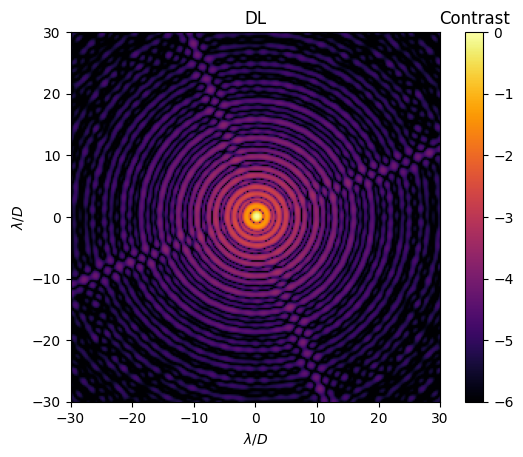

In [ ]:
cascading_dir = '/raid1/mmenessini/results/Cascading'
xao_dir = '/raid1/mmenessini/results/XAO'
ekarus_dir = '/raid1/mmenessini/results/EKARUS'
calib_dir = '/raid1/mmenessini/calibration/XAO'

oversampling = 4
pupil_tag = 'vlt_pupil_160pixels'
psf_dl = get_reference_psf(root_dir=calib_dir,pupil_tag=pupil_tag,nd=oversampling)
# pupil_tag = 'copernico_pupil_120pixels'
# psf_dl = get_reference_psf(root_dir='/raid1/mmenessini/calibration/EKARUS',pupil_tag=pupil_tag,nd=oversampling)

show_psf(psf_dl, title='DL', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-6, maxVal=np.max(psf_dl))

Using data directory: /raid1/mmenessini/results/EKARUS/20260601_171722
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: atmo_phase2 type: <class 'numpy.ndarray'>
key: coro_psf_int type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2_int type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260525_170654
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


KeyError: 'dm1_res'

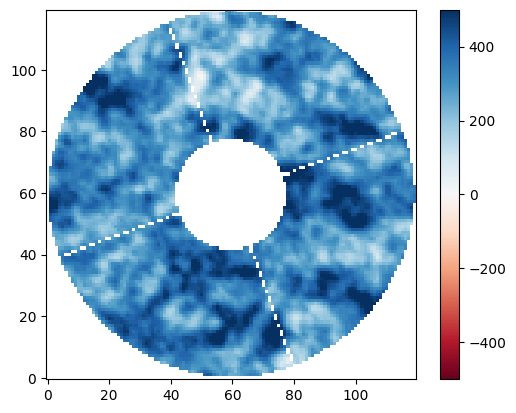

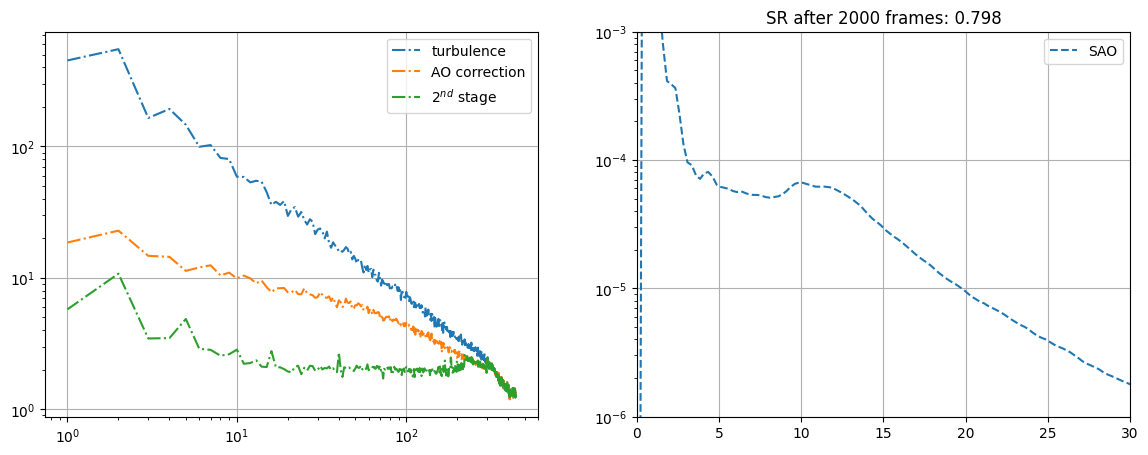

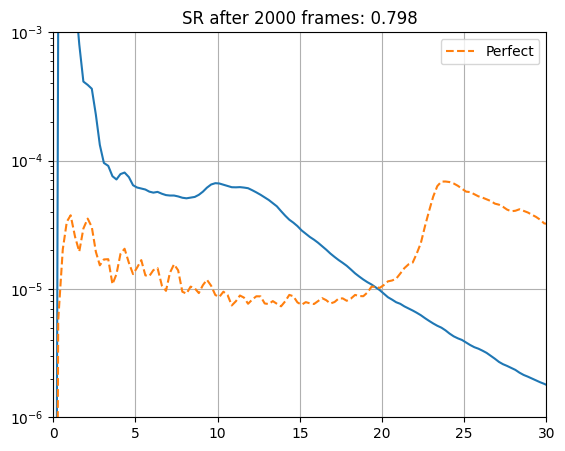

In [7]:
data = get_sim_data(root_dir=ekarus_dir)#,tn='20260527_122941') #,tn='20260527_122941

try:
    amps = data['atmo_phase'][:,0,:,:]
    phases = data['atmo_phase'][:,1,:,:]
    mask = data['atmo_phase'][0,0,:,:]==0
    plt.figure()
    plt.imshow(np.ma.masked_array(phases[1000]-np.mean(phases[1000]),mask=mask),origin='lower',cmap='RdBu',vmin=-500,vmax=500)
    plt.colorbar()
except KeyError:
    pass
try:
    init = int(1.0/0.0005)    
    coro_profile = data['coro_psf2'][0]
    sr = data['sr2']
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,2)
    plt.semilogy(coro_profile[0],coro_profile[1]*oversampling**2,'--',label='SAO')
    plt.ylim([1e-6,1e-3])
    plt.xlim([0,30])
    plt.title(f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
    plt.legend()
    plt.grid()
    mode_rms = lambda vec: np.sqrt(np.mean(vec**2,axis=0))
    atmo_rms = mode_rms(data['atmo_res'][init:])
    dm1_rms = mode_rms(data['dm_res'][init:])
    x = np.arange(len(atmo_rms))+1
    plt.subplot(1,2,1)
    plt.loglog(x,atmo_rms,'-.',label='turbulence')
    plt.loglog(x,dm1_rms,'-.',label=r'AO correction')
    try:
        dm2_rms = mode_rms(data['dm2_res'][init:])
        plt.loglog(x,dm2_rms,'-.',label=r'$2^{nd}$ stage')
    except KeyError:
        pass
    plt.legend()
    plt.grid()
except KeyError:
    pass

try:
    coro_std = data['coro_psf_std_profile'][0]
    coro_int = data['coro_psf_int_profile'][0]
    plt.figure()
    line, = plt.semilogy(coro_int[0], coro_int[1]*oversampling**2, '--', label='INT')
    plt.fill_between(
        coro_int[0],
        np.maximum(coro_int[1]*oversampling**2 - coro_std[1]*oversampling**2, 1e-20),
        coro_int[1]*oversampling**2 + coro_std[1]*oversampling**2,
        color=line.get_color(),
        alpha=0.25,
        linewidth=0
    )
    plt.ylim([1e-7,1e-3])
    plt.xlim([0,30])
    plt.legend()
    plt.grid()
except KeyError:
    init = int(0.5/0.00025)    
    try:
        sr = data['sr2']
    except KeyError:
        sr = data['sr1']
    ref_data = get_sim_data(root_dir=xao_dir,tn='20260525_170654')
    coro_std = ref_data['coro_psf_std_profile'][0]
    coro_int = ref_data['coro_psf_int_profile'][0]
    try:
        coro_profile = data['coro_psf2'][0]
    except KeyError:
        coro_profile = data['coro_psf1'][0]
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,2)
    plt.semilogy(coro_profile[0], coro_profile[1]*oversampling**2)
    line, = plt.semilogy(coro_int[0], coro_std[1]*oversampling**2, '--', label='Perfect')
    # plt.fill_between(
    #     coro_profile[0],
    #     np.maximum((coro_int[1] - coro_std[1])*oversampling**2, 1e-20),
    #     (coro_int[1] + coro_std[1])*oversampling**2,
    #     color=line.get_color(),
    #     alpha=0.25,
    #     linewidth=0
    # )
    plt.ylim([1e-6,1e-3])
    plt.xlim([0,30])
    plt.title(f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
    plt.legend()
    plt.grid()

    mode_rms = lambda vec: np.sqrt(np.mean(vec**2,axis=0))
    atmo_rms = mode_rms(data['atmo_res'][init:])
    dm1_rms = mode_rms(data['dm1_res'][init:])
    x = np.arange(len(atmo_rms))+1
    plt.subplot(1,2,1)
    plt.loglog(x,atmo_rms,'-.',label='turbulence')
    plt.loglog(x,dm1_rms,'-.',label=r'$1^{st}$ stage')
    try:
        dm2_rms = mode_rms(data['dm2_res'][init:])
        plt.loglog(x,dm2_rms,'-.',label=r'$2^{nd}$ stage')
    except KeyError:
        pass
    plt.legend()
    plt.grid()


(4000, 400)


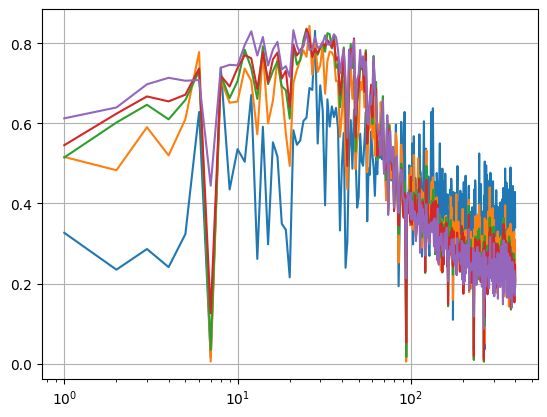

In [ ]:
print(data['opt_gains'].shape)

x = np.arange(400)+1
plt.figure()
for N in np.array([100,400,800,1000,2000]):
    plt.plot(x,np.mean(data['opt_gains'][:N,:],axis=0))
plt.grid()
plt.xscale('log')

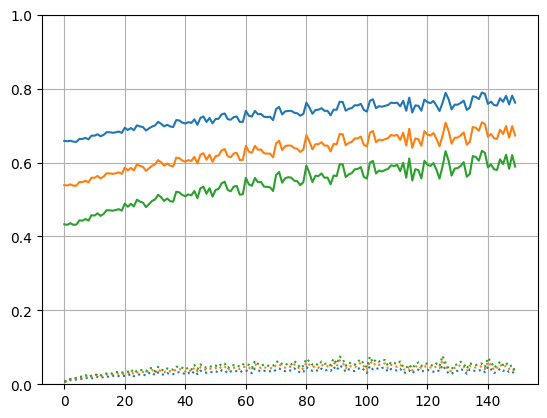

In [ ]:
simpc07 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr1.0_16x16_s0.70_150modes_simpc.fits')
simpc09 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr1.0_16x16_s0.90_150modes_simpc.fits')
simpc11 = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/im/pyr1.0_16x16_s1.10_150modes_simpc.fits')
rec = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/rec/pyr1.0_16x16_150modes_rec.fits')

og07 = np.diag(rec @ simpc07)
og09 = np.diag(rec @ simpc09)
og11 = np.diag(rec @ simpc11)

ogp07 = np.sqrt(np.sum((rec @ simpc07)**2,axis=0)-og07**2)
ogp09 = np.sqrt(np.sum((rec @ simpc09)**2,axis=0)-og09**2)
ogp11 = np.sqrt(np.sum((rec @ simpc11)**2,axis=0)-og11**2)

plt.figure()
plt.plot(og07)
plt.plot(og09)
plt.plot(og11)
plt.plot(ogp07,':',c='C0')
plt.plot(ogp09,':',c='C1')
plt.plot(ogp11,':',c='C2')
plt.ylim([0,1])
plt.grid()

In [ ]:
# frames = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr0.0_24x24_pc500modes_frames.fits')
# ref_frame = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr0.0_24x24_frame.fits')[0]

# pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/XAO/pupils/pyr_pupdata_24x24.fits')

# avg_frames = np.mean(frames,axis=0)

# thrp_ref = np.sum(ref_frame[pyr_mask])/np.sum(ref_frame)
# thrp = np.sum(avg_frames[pyr_mask])/np.sum(avg_frames)

# print(np.sum(thrp_ref))

# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1)
# plt.imshow(avg_frames,origin='lower',cmap='RdBu')
# plt.colorbar()
# plt.title(f'Throughput {thrp*1e+2:1.1f}')
# plt.subplot(1,2,2)
# plt.imshow(ref_frame,origin='lower',cmap='RdBu')
# plt.colorbar()
# plt.title(f'Throughput {thrp_ref*1e+2:1.1f}')

In [8]:

phases2 = data['atmo_phase2'][:,1,:,:]
phases = data['atmo_phase'][:,1,:,:]

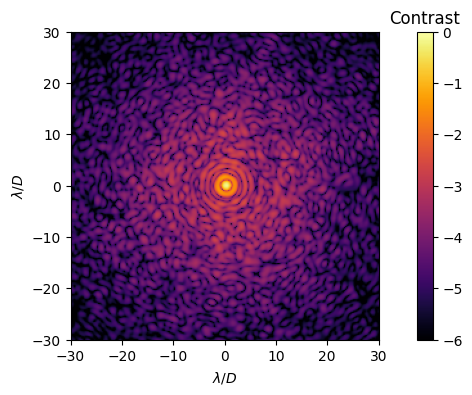

In [10]:
test_psf = calc_psf(phases2[600]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)
test_coro_psf = calc_coro_psf(phase=phases[600]*2*np.pi/750,amp=1-mask,use_average_field=True,oversampling=4)

plt.figure(figsize=(10,4))
show_psf(test_psf, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))

In [21]:

coro_psf_std = np.zeros_like(test_psf)
coro_psf_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    coro_psf_int += calc_coro_psf(phase=phases2[j]*2*np.pi/750,amp=1-mask,use_average_field=True)/N

for j in range(2000,2000+N):
    coro_psf_std += (calc_coro_psf(phase=phases2[j]*2*np.pi/750,amp=1-mask,use_average_field=True)-coro_psf_int)**2/N
coro_psf_std = np.sqrt(coro_psf_std)



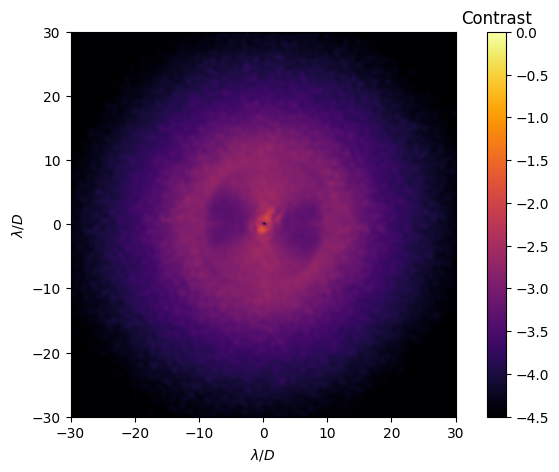

In [22]:
plt.figure(figsize=(8,5))
# plt.subplot(1,2,1)
# show_psf(coro_psf_int, cmap='inferno', ext=0.5, oversampling=4, vmin=-4.5, maxVal=np.max(psf_dl))
# plt.subplot(1,2,2)
show_psf(coro_psf_std, cmap='inferno', ext=0.5, oversampling=4, vmin=-4.5, maxVal=np.max(psf_dl))

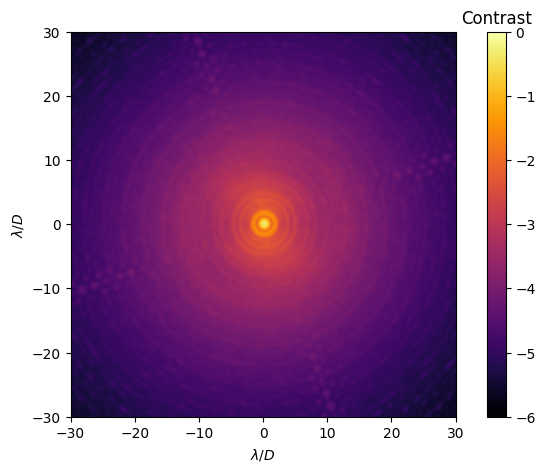

In [11]:

# psf_std = np.zeros_like(test_psf)
psf_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    psf_int += calc_psf(phases[j]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)/N

# for j in range(2000,2000+N):
#     psf_std += (calc_psf(phases[j]*2*np.pi/750, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)-psf_int)**2/N
# psf_std = np.sqrt(psf_std)

plt.figure(figsize=(8,5))
show_psf(psf_int, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))

In [12]:
# psf_std = np.zeros_like(test_psf)
psf2_int = np.zeros_like(test_psf)
N = 6000
for j in range(2000,2000+N):
    psf2_int += calc_psf(phases2[j]*2*np.pi/1450, 1-mask, imwidth=int(mask.shape[1]*oversampling), normalize=True, xp=np, complex_dtype=complex)/N

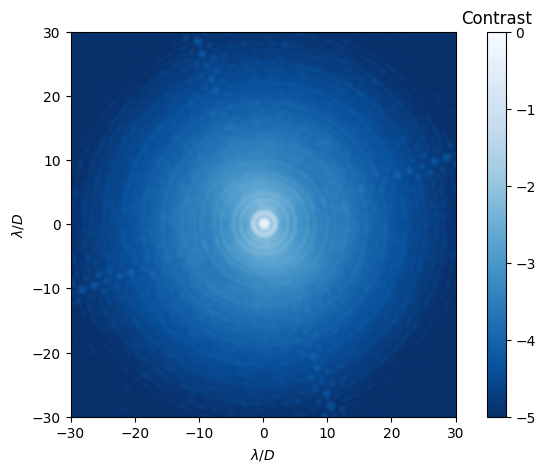

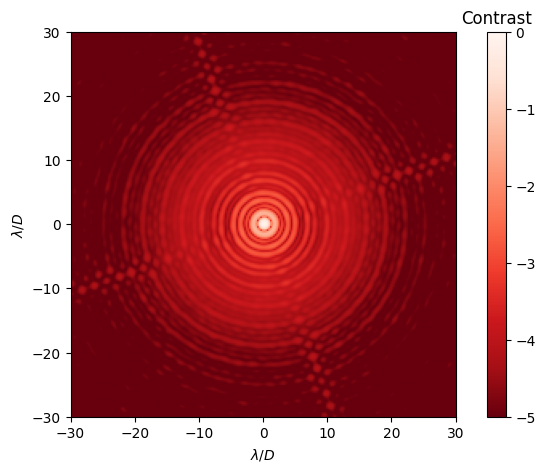

In [30]:

plt.figure(figsize=(8,5))
show_psf(psf_int, cmap='Blues_r', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))
plt.figure(figsize=(8,5))
show_psf(psf2_int, cmap='Reds_r', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))

In [49]:

ref_data = get_sim_data(root_dir=ekarus_dir,tn='20260601_174911')

Using data directory: /raid1/mmenessini/results/EKARUS/20260601_174911
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


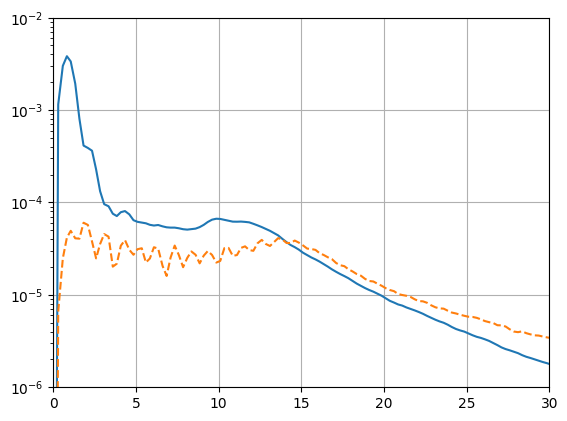

In [50]:
plt.figure()
# plt.semilogy(data['coro_psf'][0][0],data['coro_psf'][0][1]*oversampling**2/(1450/750)**2)
plt.semilogy(data['coro_psf2'][0][0],data['coro_psf2'][0][1]*oversampling**2)
plt.semilogy(ref_data['coro_psf_std_profile'][0][0],ref_data['coro_psf_std_profile'][0][1]*oversampling**2,'--')
plt.ylim([1e-6,1e-2])
plt.xlim([0,30])
plt.grid()

In [ ]:
rad_coro_psf, dist = compute_radial_profile(coro_psf_std)
data = get_sim_data(root_dir=cascading_dir,tn='20260527_122941')
ref_data = get_sim_data(root_dir=xao_dir,tn='20260525_170654')
coro_std = ref_data['coro_psf_std_profile'][0]
coro = data['coro_psf1'][0]

plt.figure()    
plt.semilogy(dist/oversampling,rad_coro_psf,'--',label='SAO')
plt.semilogy(coro[0],coro[1]*oversampling**2,'--')
# plt.semilogy(coro_std[0],coro_std[1]*oversampling**2,':',c='k',label='Perfect')
plt.ylim([1e-6,1e-3])
plt.xlim([0,30])
plt.title('Coronagraphic PSF radial profile') #f'SR after {init} frames: {np.mean(sr[init:]):1.3f}')
plt.ylabel(r'1-$\sigma$ contrast')
plt.xlabel(r'$\lambda/D$')
# plt.legend()
plt.grid()

NameError: name 'compute_radial_profile' is not defined

In [ ]:
tn1kHz = '20260520_102745'
tn2kHz = '20260520_110242'
tn4kHz = '20260520_115326'
tnMod1 = '20260520_120617'
tnMod0 = '20260520_123548'

# Cascading
tnSAO = '20260521_170926' # cascading_iirfilter_1300modes, g = 0.15
tnCAO = '20260521_172032' # int g=0.4, iirfilter_300modes g = 0.2

Using data directory: /raid1/mmenessini/results/Cascading/20260521_170926
key: sr1 type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: coro_psf1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/Cascading/20260521_172032
key: sr1 type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: coro_psf1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>


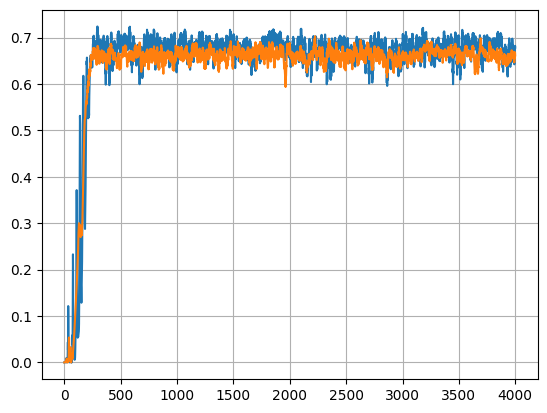

In [ ]:
dataSAO = get_sim_data(root_dir=cascading_dir,tn=tnSAO)
dataCAO = get_sim_data(root_dir=cascading_dir,tn=tnCAO)

sr = dataSAO['sr2']
srCAO = dataCAO['sr2']

plt.figure()
plt.plot(sr)
plt.plot(srCAO)
plt.grid()

Using data directory: /raid1/mmenessini/results/XAO/20260520_102745
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_110242
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_115326
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <

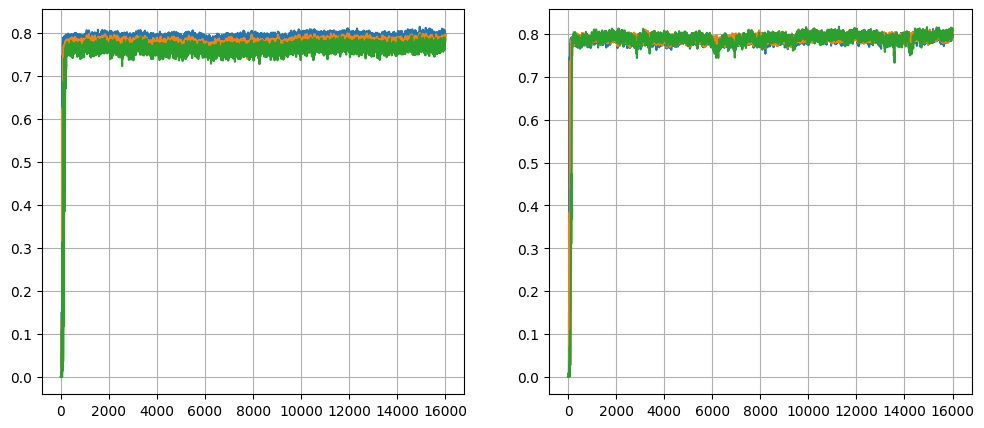

In [ ]:
data1kHz = get_sim_data(root_dir=xao_dir,tn=tn1kHz)
data2kHz = get_sim_data(root_dir=xao_dir,tn=tn2kHz)
data4kHz = get_sim_data(root_dir=xao_dir,tn=tn4kHz)
dataMod1 = get_sim_data(root_dir=xao_dir,tn=tnMod1)
dataMod0 = get_sim_data(root_dir=xao_dir,tn=tnMod0)

sr1k = data1kHz['sr']
sr2k = data2kHz['sr']
sr4k = data4kHz['sr']
sr1 = dataMod1['sr']
sr0 = dataMod0['sr']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(sr4k)
plt.plot(sr2k)
plt.plot(sr1k)
plt.grid()
plt.subplot(1,2,2)
plt.plot(sr4k)
plt.plot(sr1)
plt.plot(sr0)
plt.grid()

In [ ]:
dt = 0.00025
init = int(0.5/dt)

In [ ]:
coro_psf1kHz = data1kHz['coro_psf']
opt_coro_psf = data1kHz['coro_opt_psf']

coro_psf1kHz_std = np.sqrt(np.mean(coro_psf1kHz[init:]**2,axis=0))
opt_coro_psf_std = np.std(opt_coro_psf,axis=0) #np.sqrt(np.mean(opt_coro_psf[init:]**2,axis=0))

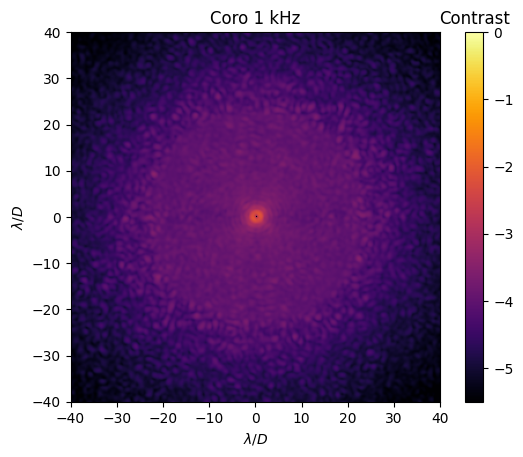

In [ ]:
coro_psf = dataSAO['coro_psf2']
coro_psf_std = np.mean(coro_psf[init:],axis=0) #[init:]**2
plt.figure()
show_psf(coro_psf_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

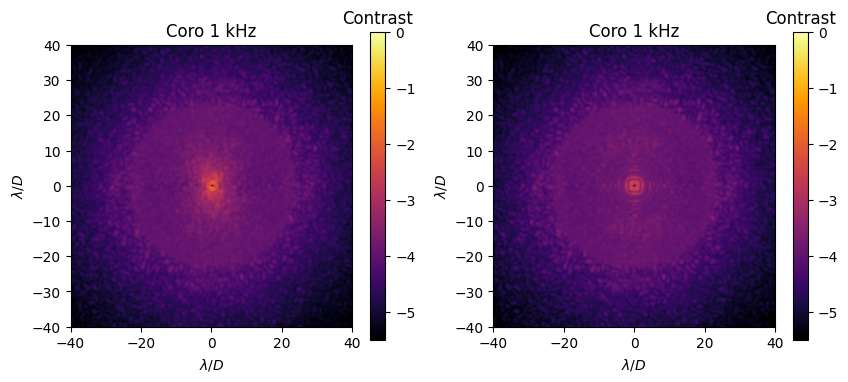

In [ ]:
coro_psf1 = dataCAO['coro_psf1']
coro_psf1_std = np.mean(coro_psf1[init:],axis=0) #[init:]**2
coro_psf2 = dataCAO['coro_psf2']
coro_psf2_std = np.mean(coro_psf2[init:],axis=0) #[init:]**2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_psf(coro_psf1_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,2,2)
show_psf(coro_psf2_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
coro_psf2kHz = data2kHz['coro_psf']
coro_psf2kHz_std = np.sqrt(np.mean(coro_psf2kHz[init:]**2,axis=0))

coro_psf4kHz = data4kHz['coro_psf']
coro_psf4kHz_std = np.sqrt(np.mean(coro_psf4kHz[init:]**2,axis=0))

In [ ]:
coro_psfmod1 = dataMod1['coro_psf']
coro_psfmod1_std = np.sqrt(np.mean(coro_psfmod1[init:]**2,axis=0))

coro_psfmod0 = dataMod0['coro_psf']
coro_psfmod0_std = np.sqrt(np.mean(coro_psfmod0[init:]**2,axis=0))

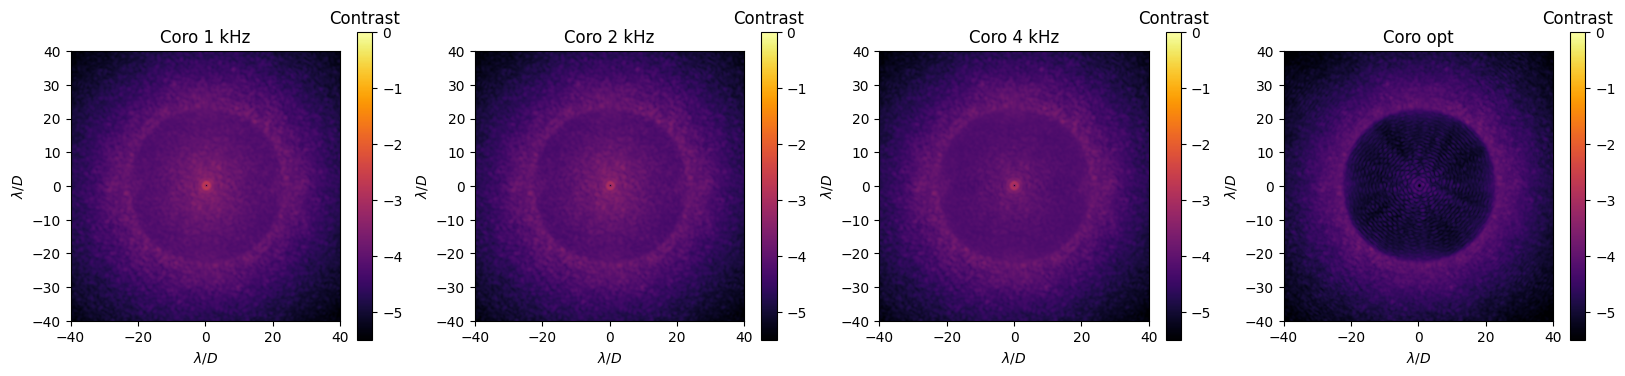

In [ ]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf1kHz_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psf2kHz_std, title='Coro 2 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psf4kHz_std, title='Coro 4 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

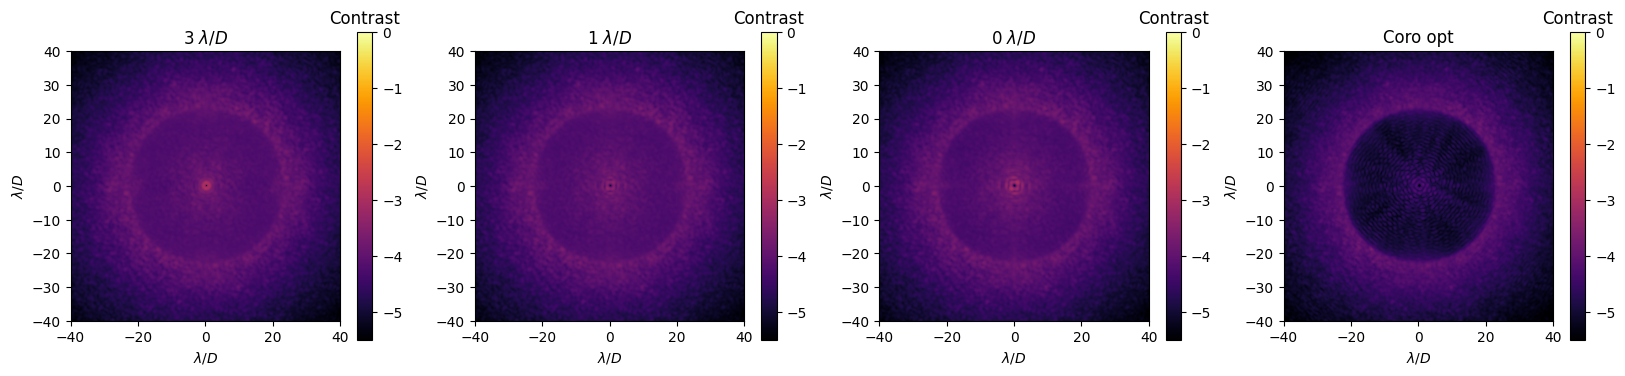

In [ ]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf4kHz_std, title=r'3 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psfmod1_std, title=r'1 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psfmod0_std, title=r'0 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
# rad_psf_dl, dist = compute_radial_profile(psf_dl)
rad_psf1kHz_coro, dist = compute_radial_profile(coro_psf1kHz_std)
rad_psf2kHz_coro, dist = compute_radial_profile(coro_psf2kHz_std)
rad_psf4kHz_coro, dist = compute_radial_profile(coro_psf4kHz_std)
rad_psfmod1_coro, dist = compute_radial_profile(coro_psfmod1_std)
rad_psfmod0_coro, dist = compute_radial_profile(coro_psfmod0_std)
rad_psf_opt_coro, dist = compute_radial_profile(opt_coro_psf_std)
# rad_psf2kHz_opt_coro, dist = compute_radial_profile(opt_coro_psf2kHz_std)

Text(0.5, 0, '$\\lambda/D$')

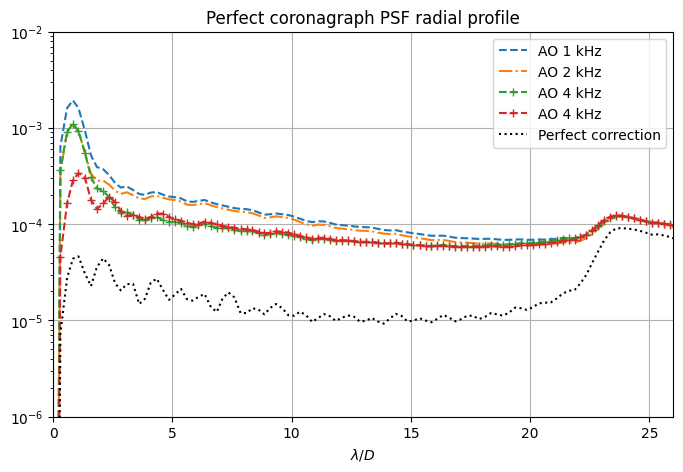

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(dist/oversampling, rad_psf1kHz_coro/np.max(psf_dl), '--', label=r'AO 1 kHz')
plt.plot(dist/oversampling, rad_psf2kHz_coro/np.max(psf_dl), '-.', label=r'AO 2 kHz')
plt.plot(dist/oversampling, rad_psf4kHz_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psfmod1_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
# plt.plot(dist/oversampling, rad_psfmod0_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psf_opt_coro/np.max(psf_dl), ':', c='k', label=r'Perfect correction')
plt.legend()
plt.yscale('log')
plt.xlim([0,26])
plt.ylim([1e-6,1e-2])
plt.grid()
plt.title('Perfect coronagraph PSF radial profile')
plt.xlabel(r'$\lambda/D$')